In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import plotly as py
import plotly.graph_objs as go

In [2]:
#Leo el dataset
df = pd.read_csv('online_shoppers_intention.csv')

In [3]:
#Un pequeño analisis de dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
#Miramos a ver si hay algun valor nulo
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [33]:
#Estamos usando KMeans, conviene normalizar los datos
x = df.iloc[:, [5, 6]].values

#from sklearn.preprocessing import StandardScaler
#sc = StandardScaler()
#x = sc.fit_transform(x)

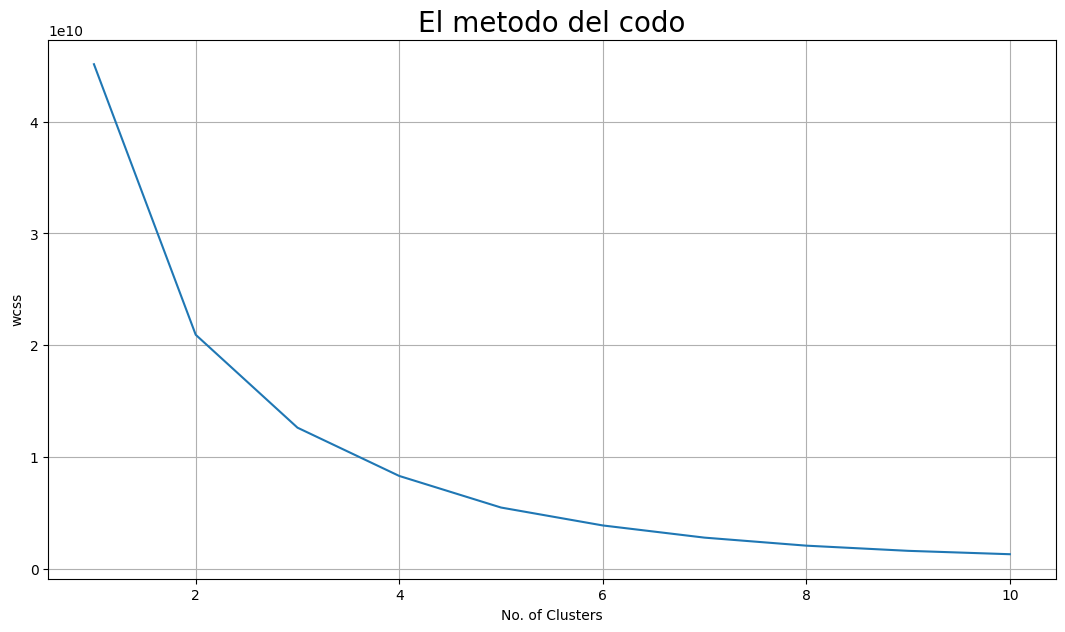

In [34]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i,
        init='k-means++',
        n_init = 10,
        max_iter = 300,
        random_state = 0,
        tol=0.001)
    km.fit(x)
    labels = km.labels_
    wcss.append(km.inertia_)

plt.rcParams['figure.figsize'] = (13, 7) #esto es para settear siempre el mismo tamaño de las figuras
plt.plot(range(1,11), wcss)
plt.grid()
plt.title('El metodo del codo', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss') #wcss es la metrica que nos dice como de bien separados estan los clusters, cuanto mas bajo mejor
plt.show()


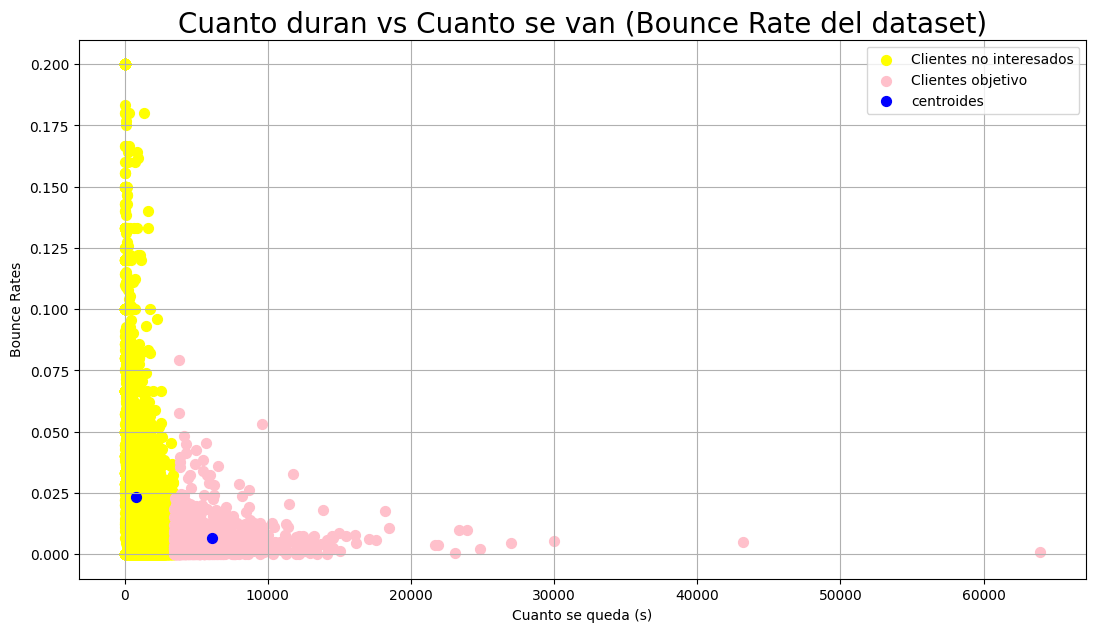

In [35]:
#Segun fuentes, hay gente que escoge 2 o escoge 3, o voy a escoger 2, aunque tres tampoco es una mala elección
knn_final = KMeans(n_clusters=2,init='k-means++', n_init = 10, max_iter = 300, random_state = 0)
y_means = knn_final.fit_predict(x)

plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s = 50, c = 'yellow', label = 'Clientes no interesados')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s = 50, c = 'pink', label = 'Clientes objetivo') #si añades mas aqui hay que meter mas codigo
plt.scatter(knn_final.cluster_centers_[:,0], knn_final.cluster_centers_[:, 1], s = 50, c = 'blue' , label = 'centroides')

plt.title('Cuanto duran vs Cuanto se van (Bounce Rate del dataset)', fontsize = 20)
plt.grid()
plt.xlabel('Cuanto se queda (s)')
plt.ylabel('Bounce Rates')
plt.legend()
plt.show()

ARI:  0.08359442469281096
Matriz de confusion: 
 [[9774  648]
 [1625  283]]
Matriz de confusion normalizada: 
 [[0.93782383 0.06217617]
 [0.85167715 0.14832285]]


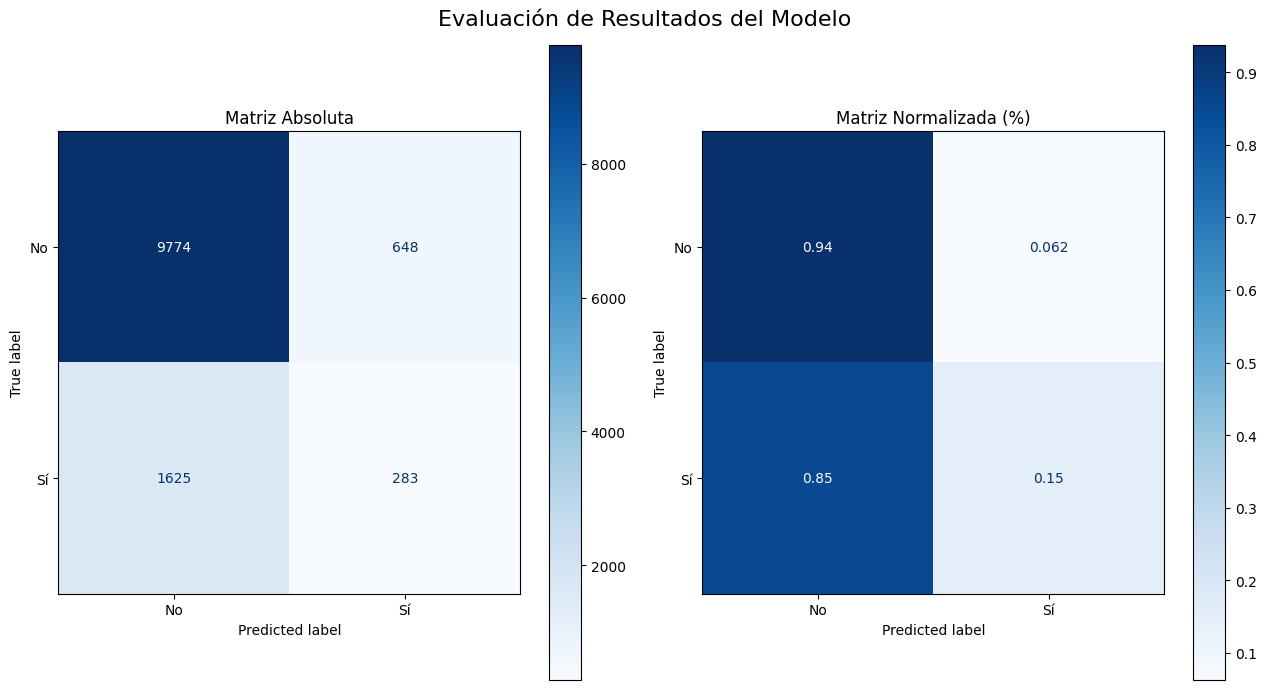

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
objetivo = le.fit_transform(df['Revenue'])
predicho = y_means

from sklearn import metrics
score = metrics.adjusted_rand_score(objetivo, predicho) #esto es el ari que es la metrica por excelencia cuando sabemos el objetivo
print('ARI: ', score)

fig,ax = plt.subplots(1,2)
confusion = metrics.confusion_matrix(objetivo, predicho)
confusion_norm = metrics.confusion_matrix(objetivo, predicho,normalize='true')
print('Matriz de confusion: \n', confusion)
print('Matriz de confusion normalizada: \n', confusion_norm)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=['No', 'Sí'])
disp.plot(ax=ax[0], cmap='Blues')
ax[0].set_title("Matriz Absoluta") # Título para la primera gráfica
disp_norm = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_norm, display_labels=['No', 'Sí'])
disp_norm.plot(ax=ax[1], cmap='Blues')
ax[1].set_title("Matriz Normalizada (%)") # Título para la segunda gráfica

# 5. Título general para toda la imagen
plt.suptitle("Evaluación de Resultados del Modelo", fontsize=16)

# Ajusta el espacio para que no se pisen los títulos
plt.tight_layout()
plt.show()


"""Como vemos A pesar de que el algoritmo K-Means logra separar a los 
usuarios en grupos basados en su tiempo de estancia y tasa de rebote,
existe una débil correlación entre estas métricas de navegación y la conversión final (Revenue)."""